In [22]:
# Reading in the data and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

districts = pd.read_csv('district_level_expanded.csv')
districts['Council District'] = districts['Council District'].astype('category')
y = districts['confirmed_calls']
X = pd.get_dummies(districts.drop(columns=['council_district_name','confirmed_calls', 'confirmed_rate_per_1000']), drop_first=False)
district_numbers = districts['Council District']

In [23]:
# Creating test and training sets
X_train, X_test, y_train, y_test, dist_train, dist_test = train_test_split(X, y, district_numbers, test_size=0.25, random_state = 307)

In [24]:
# Creating random forest model and making predictions
FOREST = RandomForestRegressor(n_estimators=500, random_state = 307, oob_score=True, n_jobs=-1)
FOREST.fit(X_train,y_train)

y_pred = FOREST.predict(X_test)

In [25]:
# Viewing the predictions to see if they make sense
results = pd.DataFrame({
    'Council District': dist_test,
    'Predicted Confirmed Calls': y_pred
})

print(results)

   Council District  Predicted Confirmed Calls
18               19                     70.722
47               48                    107.318
40               41                    288.196
30               31                     85.364
13               14                    228.650
35               36                    319.532
4                 5                    234.850
28               29                    107.918
44               45                    218.730
25               26                    147.448
12               13                    123.206
46               47                    112.984
41               42                    124.438


In [26]:
# RMSE for the model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("RMSE:", np.sqrt(mse))

RMSE: 60.163761267445324


In [27]:
# RMSE from a LOO CV
from sklearn.model_selection import LeaveOneOut, cross_val_score

loo = LeaveOneOut()
scores = cross_val_score(FOREST, X, y, cv=loo, scoring='neg_mean_squared_error')
rmse = (np.sqrt(-scores.mean()))
print("RMSE:", rmse)

RMSE: 55.59044225298405


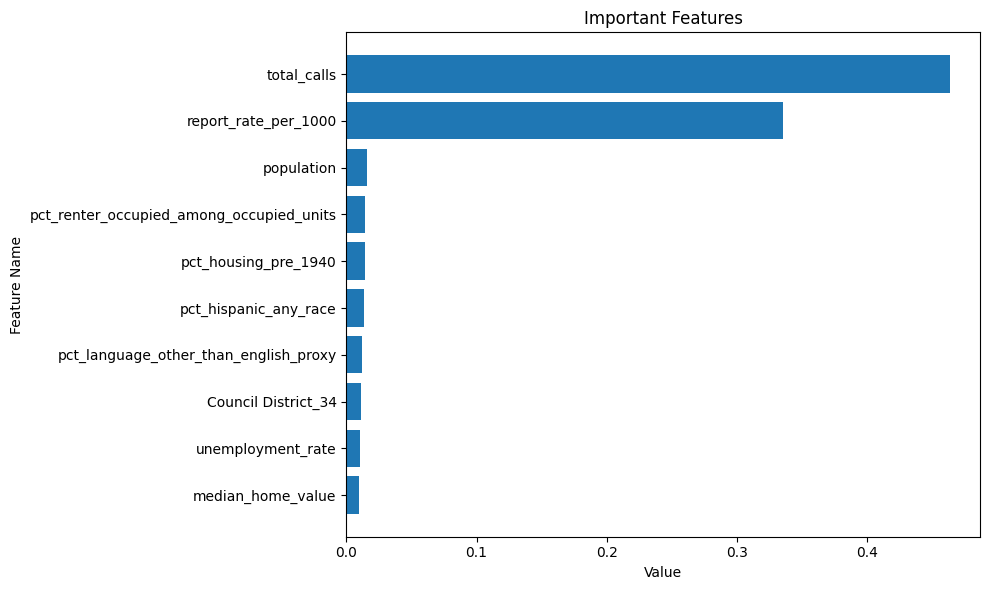

In [28]:
feat_imp = FOREST.feature_importances_

feature_names = X_train.columns
sorted_idx = np.argsort(feat_imp)[::-1]

sorted_feat_imp = feat_imp[sorted_idx][0:10]
sorted_features = feature_names[sorted_idx][0:10]

plt.figure(figsize=(10,6))
plt.barh(sorted_features, sorted_feat_imp)

plt.xlabel("Value")
plt.ylabel("Feature Name")
plt.title("Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()